# 06. Customizing and Annotating Visualizations

## For Presentations

## 📚 Learning Objectives

By completing this notebook, you will:
- Customize visualizations (colors, fonts, styles)
- Add annotations (text, arrows, highlights)
- Format charts for professional presentations
- Use consistent styling and themes
- Export publication-quality plots

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 3, lesson 02 "Matplotlib Fundamentals" — the axes object is what annotations, colours and themes attach to.

**Used later in:** Course 05 — Unit 3, lesson 07, which asks which of these choices actually help the reader.

---

This notebook covers practical activities from **Course 05, Unit 3**:
- Customizing and annotating visualizations for presentations

---

## The Story: Polishing Your Work

Imagine you've written a report (created a chart). **Before** presenting, you polish it - add formatting, highlight key points, make it professional. **After** polishing, your work is presentation-ready!

Same with visualization: **After** creating basic charts, we customize - add colors, fonts, annotations. **After** customizing, charts are professional and presentation-ready!

---

## Why Customization and Annotation Matter

Customization and annotation are essential because:
- **Clarity**: Clear charts communicate better
- **Professionalism**: Well-designed charts impress
- **Insights**: Annotations highlight key findings
- **Consistency**: Consistent styling creates cohesive presentations

**Common Student Questions:**
- **Q: What should I customize?**
  - Answer: Colors, fonts, labels, titles, legends, grid
  - Example: Use consistent colors, readable fonts, clear labels
  - Tip: Less is more - don't over-customize!
  
- **Q: When do I add annotations?**
  - Answer: To highlight important points, explain outliers, show trends
  - Example: Arrow pointing to peak, text explaining spike
  - Benefit: Annotations guide viewer's attention

---

## Introduction

**Customizing and annotating visualizations** transforms basic charts into professional, presentation-ready visualizations. Proper customization enhances clarity, while annotations highlight key insights.


## 🎯 The case: the default colour scheme that had to be replaced

For twenty years the default colour map in MATLAB and in matplotlib was **jet** — the
rainbow. In 2007 David Borland and Russell Taylor published *"Rainbow Color Map (Still)
Considered Harmful"* in IEEE Computer Graphics and Applications, with three specific
charges: the rainbow has **no perceptual ordering** (nobody agrees whether green is more
than yellow), its **luminance varies uncontrollably** (so it is unreadable in greyscale
and to many colour-blind readers), and it **introduces gradients that are not in the
data** — sharp apparent boundaries at the colour transitions that a reader interprets as
features.

matplotlib acted on it. Four perceptually uniform maps arrived in version 1.5, and from
**version 2.0 viridis became the default**, built in the CAM02-UCS colour space so that
equal steps in the data are equal steps in perceived lightness. In October 2020 Crameri,
Shephard and Heron went further in *Nature Communications*, documenting that visually
distorting colour maps remain widespread across published science.

**What this means for the next ninety minutes.** Every choice you are about to make —
colour, axis, annotation, emphasis — is not decoration. It is part of the claim. A colour
map that invents a boundary has invented a finding, and the reader has no way to tell.

**What goes wrong without deliberate annotation.** You will chart the real 2018 monthly
911 volume for Montgomery County against the 2017 monthly average — **441 calls a month** in
the 25,000-call sample this repository ships (1 call in 27 of a 663,522-call log that is too
big to commit; the full-file figure is about 27 times larger). The year's shape is
unremarkable until somebody marks it: **10 of the 12 months ran above the previous year's
average**. That ratio is a property of the data, not of the sample size. The data always
contained it. The annotation is what makes a reader see it.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `montgomery_911_calls` — real 911 dispatches in Montgomery County,
  Pennsylvania (Dec 2015 – Jul 2020). The full log is 663,522 calls and is not in this
  repository; **what runs here is the 25,000-call sample that is** (`prefer="sample"`,
  1 call in 27). We chart the 2018 monthly call volume against the 2017 monthly average
  as a benchmark line — both counts are a twenty-seventh of the county's real volume, and
  the comparison between them is unaffected.
- matplotlib, seaborn, pandas

**Outputs:** What you'll see when you run the cells

- The same real series drawn four ways: styled, annotated, highlighted, publication-ready
- A peak annotation and per-month markers computed from the data, never hard-coded

---


In [1]:
# WHAT: Import libraries, set a professional style, and load the real series we will style.
# WHY: Customization is best learned on ONE honest series - the techniques, not the numbers, are the lesson.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set professional style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported!")
print("\n" + "=" * 70)
print("Customizing and Annotating Visualizations")
print("=" * 70)

# ============================================================================
# ============================================================================
print("-" * 70)

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------

# Real data: the Montgomery County (PA) 911 dispatch log.
calls = load("montgomery_911_calls", prefer="sample",
             usecols=['timeStamp'], parse_dates=['timeStamp'])

# 2018 monthly call volume - the series we will style and annotate.
y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
monthly = y2018.groupby(y2018['timeStamp'].dt.month).size()

# Benchmark line: the 2017 monthly average. A real reference point, not an invented target.
y2017 = calls[(calls['timeStamp'] >= '2017-01-01') & (calls['timeStamp'] < '2018-01-01')]
baseline_2017 = y2017.groupby(y2017['timeStamp'].dt.month).size().mean()

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = pd.DataFrame({
    'month': MONTH_NAMES,
    'calls': monthly.reindex(range(1, 13)).values,
    'baseline': [baseline_2017] * 12,
})

print(f"Real 2018 monthly 911 call volume (benchmark = 2017 monthly average "
      f"= {baseline_2017:,.0f} calls):")
print(data.round(0).to_string(index=False))

✅ Libraries imported!

Customizing and Annotating Visualizations
----------------------------------------------------------------------
montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Real 2018 monthly 911 call volume (benchmark = 2017 monthly average = 441 calls):
month  calls  baseline
  Jan    495     441.0
  Feb    420     441.0
  Mar    563     441.0
  Apr    423     441.0
  May    473     441.0
  Jun    456     441.0
  Jul    473     441.0
  Aug    464     441.0
  Sep    465     441.0
  Oct    489     441.0
  Nov    531     441.0
  Dec    458     441.0



PART 2: Customization

✅ Example 1: Colors and Styles
----------------------------------------------------------------------


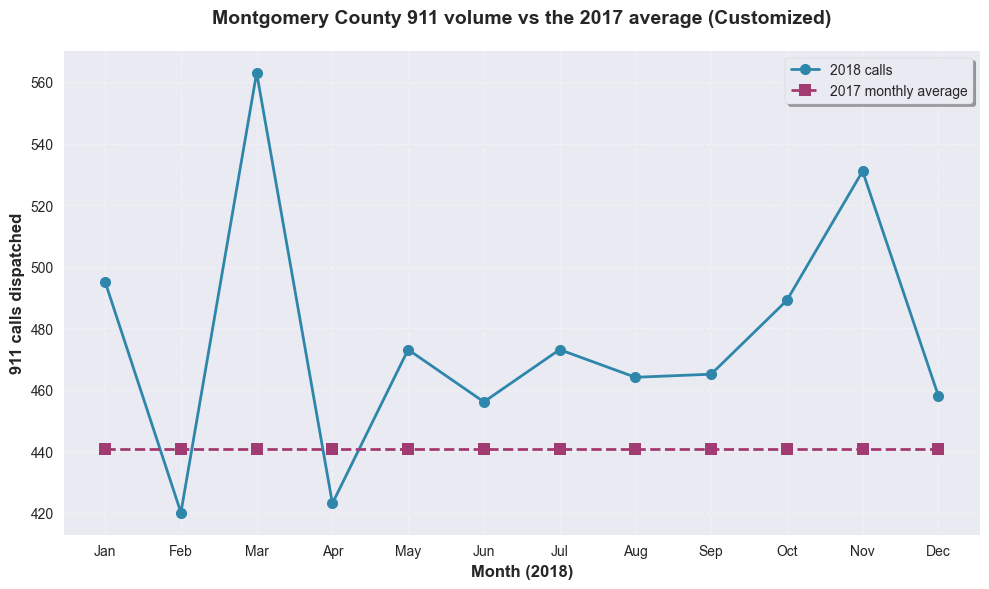

💡 Customized: Colors, fonts, line styles, grid, legend

✅ Example 2: Professional Styling comes next - see the bar chart below


In [2]:
# WHAT: Style the real 2018 call series - colours, line styles, fonts, grid and legend.
# WHY: Defaults communicate nothing; deliberate styling is what makes a chart readable at a glance.

# ============================================================================
# PART 2: CUSTOMIZATION
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Customization")
print("=" * 70)

# Example 1: Colors and Styles
print("\n✅ Example 1: Colors and Styles")
print("-" * 70)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data['month'], data['calls'], marker='o', linewidth=2,
        markersize=8, color='#2E86AB', label='2018 calls', linestyle='-')
ax.plot(data['month'], data['baseline'], marker='s', linewidth=2,
        markersize=8, color='#A23B72', label='2017 monthly average', linestyle='--')
ax.set_xlabel('Month (2018)', fontsize=12, fontweight='bold')
ax.set_ylabel('911 calls dispatched', fontsize=12, fontweight='bold')
ax.set_title('Montgomery County 911 volume vs the 2017 average (Customized)',
             fontsize=14, fontweight='bold', pad=20)
# upper RIGHT: the March peak (14,923) is on the left and the February trough (11,165)
# is at the bottom - the top-right corner is the only empty quarter of this chart.
ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print("💡 Customized: Colors, fonts, line styles, grid, legend")

print("\n✅ Example 2: Professional Styling comes next - see the bar chart below")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.


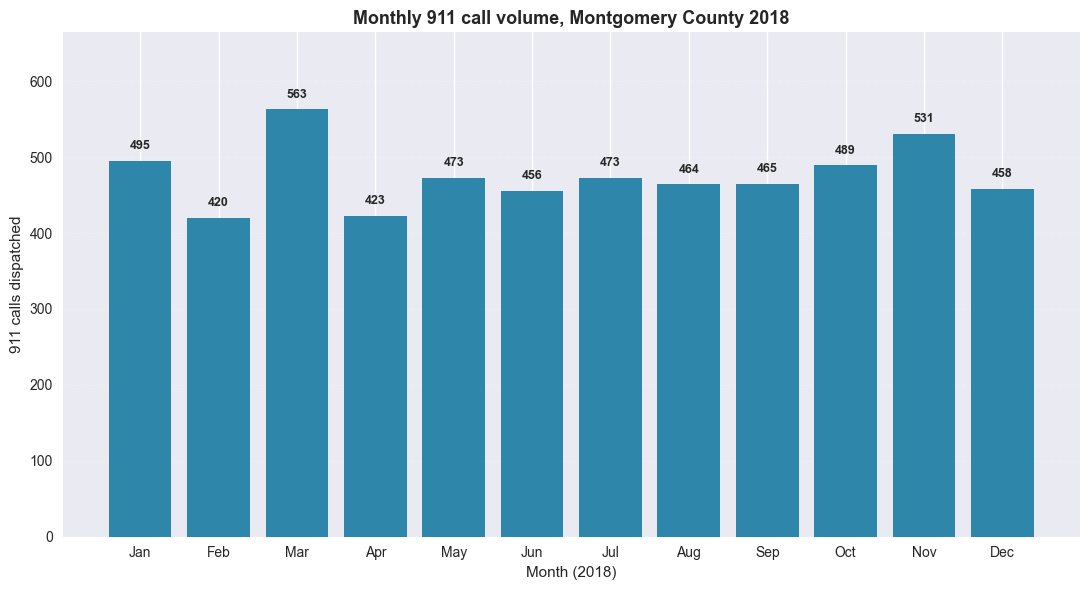

💡 Professional: Consistent colors, value labels, clean design

PART 3: Annotations

✅ Example 3: Text Annotations
----------------------------------------------------------------------


In [3]:
# WHAT: Draw a styled bar chart of the real monthly volume - custom colors, labels, grid, and value annotations.
# WHY: Titles, axis labels, and direct value labels are the difference between a draft and a chart you can present.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load() comes from the data-setup cell in Part 1 above - run that cell first.
# The data is re-read here so re-running this one cell still works.

# Real data: the Montgomery County (PA) 911 dispatch log.
calls = load("montgomery_911_calls", prefer="sample",
             usecols=['timeStamp'], parse_dates=['timeStamp'])

# 2018 monthly call volume - the series we will style and annotate.
y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
monthly = y2018.groupby(y2018['timeStamp'].dt.month).size()

# Benchmark line: the 2017 monthly average. A real reference point, not an invented target.
y2017 = calls[(calls['timeStamp'] >= '2017-01-01') & (calls['timeStamp'] < '2018-01-01')]
baseline_2017 = y2017.groupby(y2017['timeStamp'].dt.month).size().mean()

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = pd.DataFrame({
    'month': MONTH_NAMES,
    'calls': monthly.reindex(range(1, 13)).values,
    'baseline': [baseline_2017] * 12,
})

# Create figure for plotting
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(data['month'], data['calls'], color='#2E86AB')
ax.set_xlabel('Month (2018)', fontsize=11)
ax.set_ylabel('911 calls dispatched', fontsize=11)
ax.set_title('Monthly 911 call volume, Montgomery County 2018',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, data['calls'].max() * 1.18)
ax.grid(True, alpha=0.2, axis='y', linestyle='--')

# Add value labels on bars - read straight from the data, never typed by hand
for i, (month, n) in enumerate(zip(data['month'], data['calls'])):
    ax.text(i, n + data['calls'].max() * 0.02, f'{n:,}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
print("💡 Professional: Consistent colors, value labels, clean design")

# ============================================================================
# PART 3: ANNOTATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Annotations")
print("=" * 70)

# Example 3: Text Annotations
print("\n✅ Example 3: Text Annotations")
print("-" * 70)



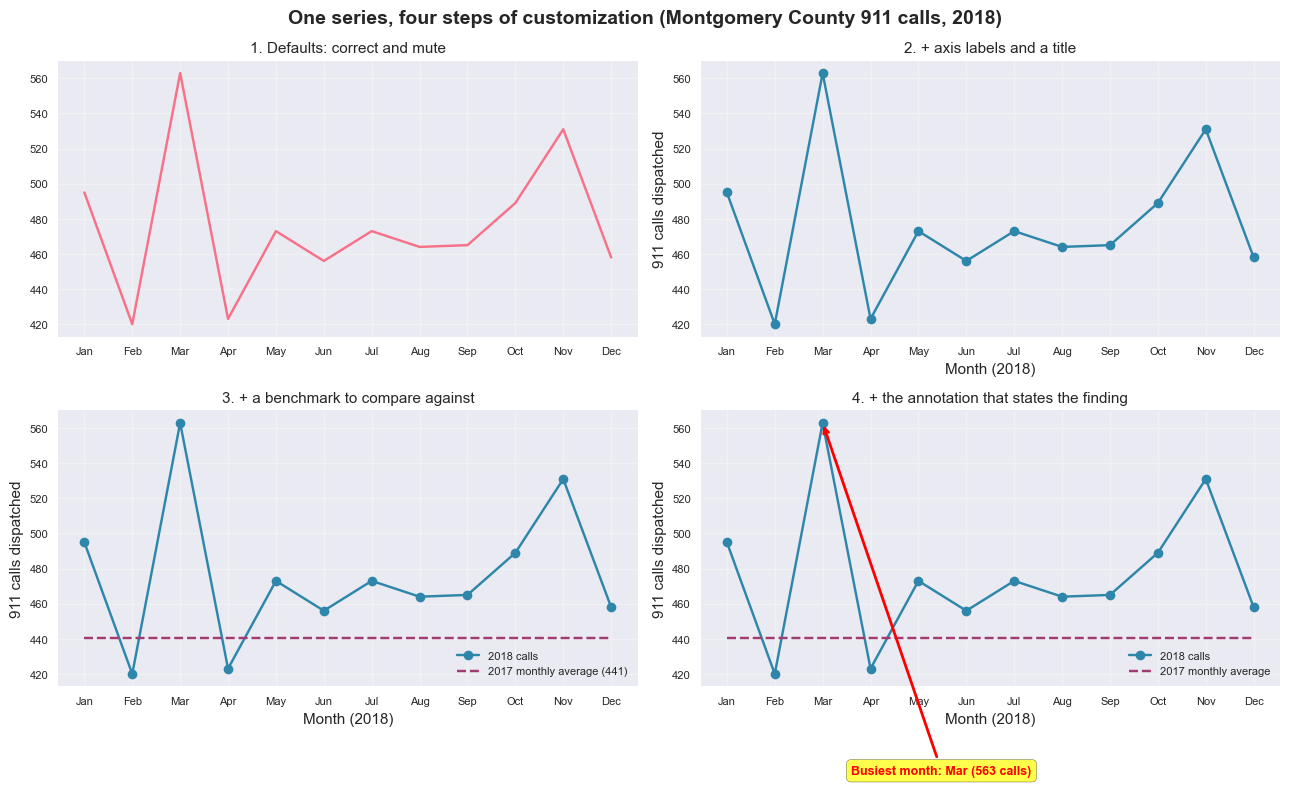

💡 Annotations: Highlight key points, explain patterns (peak read from the data: Mar = 563 calls)
   Step 1 and step 4 draw the SAME twelve numbers (420 to 563).

✅ Example 1: Multiple Annotations
----------------------------------------------------------------------


In [4]:
# WHAT: Build the SAME real series four times, adding one layer of customization each step,
#       and finish with the arrow that states the finding.
# WHY: Customization is a sequence of decisions, not a switch. Seeing the four steps side by side
#      shows exactly what each decision bought the reader.

# The busiest month, read from the data - never typed in by hand.
peak_idx = data['calls'].idxmax()
peak_month = data.loc[peak_idx, 'month']
peak_value = data.loc[peak_idx, 'calls']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('One series, four steps of customization (Montgomery County 911 calls, 2018)',
             fontsize=14, fontweight='bold')

# STEP 1 - what matplotlib gives you for free. Correct, and says nothing.
ax = axes[0, 0]
ax.plot(data['month'], data['calls'])
ax.set_title('1. Defaults: correct and mute', fontsize=11)

# STEP 2 - the reader now knows what the axes mean. This is the minimum honest chart.
ax = axes[0, 1]
ax.plot(data['month'], data['calls'], marker='o', color='#2E86AB')
ax.set_title('2. + axis labels and a title', fontsize=11)
ax.set_xlabel('Month (2018)')
ax.set_ylabel('911 calls dispatched')

# STEP 3 - a benchmark turns a shape into a comparison: high or low COMPARED TO WHAT?
ax = axes[1, 0]
ax.plot(data['month'], data['calls'], marker='o', color='#2E86AB', label='2018 calls')
ax.plot(data['month'], data['baseline'], linestyle='--', color='#A23B72',
        label=f'2017 monthly average ({baseline_2017:,.0f})')
ax.set_title('3. + a benchmark to compare against', fontsize=11)
ax.set_xlabel('Month (2018)')
ax.set_ylabel('911 calls dispatched')
ax.legend(fontsize=8, loc='lower right')

# STEP 4 - the annotation names the finding. Its text and its position are computed,
# so they stay correct if the log is updated.
ax = axes[1, 1]
ax.plot(data['month'], data['calls'], marker='o', color='#2E86AB', label='2018 calls')
ax.plot(data['month'], data['baseline'], linestyle='--', color='#A23B72',
        label='2017 monthly average')
ax.annotate(f'Busiest month: {peak_month} ({peak_value:,} calls)',
            xy=(peak_idx, peak_value),
            xytext=(peak_idx + 0.6, peak_value - 200),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=9, fontweight='bold', color='red',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7))
ax.set_title('4. + the annotation that states the finding', fontsize=11)
ax.set_xlabel('Month (2018)')
ax.set_ylabel('911 calls dispatched')
ax.legend(fontsize=8, loc='lower right')

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()
print(f"💡 Annotations: Highlight key points, explain patterns "
      f"(peak read from the data: {peak_month} = {peak_value:,} calls)")
print(f"   Step 1 and step 4 draw the SAME twelve numbers "
      f"({data['calls'].min():,} to {data['calls'].max():,}).")

# Example 1: Multiple Annotations
print("\n✅ Example 1: Multiple Annotations")
print("-" * 70)


**Read the figure.** Four panels, the same twelve real numbers (420 to 563 calls in the
bundled 1-in-27 sample), one decision added at a time. **Panel 1** is what matplotlib gives you for free: a bare line
in whatever colour the active palette happens to be, with no y-axis label — a reader cannot
tell what is being counted. **Panel 2** adds the axis labels and markers, so the shape
becomes a quantity. **Panel 3** adds the dashed 2017 average at **441**, and only now can
the reader answer "high compared to what?" — the 2018 line sits above that dashed line in
every month except February and April. **Panel 4** adds one arrow naming **March, 563
calls**, and the eye goes there first.

Nothing in the data changed between panel 1 and panel 4. What changed is how much of the
work the reader has to do, and every step of it was a decision you made on their behalf —
which is why the same technique that clarifies can also mislead.


montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.


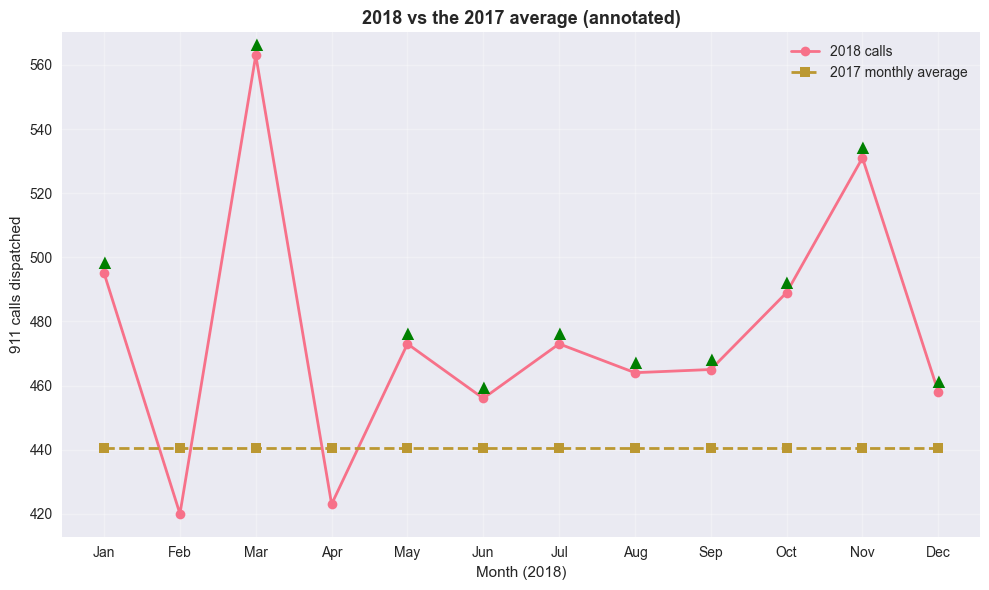

💡 Multiple annotations: 10 of 12 months in 2018 ran above the 2017 monthly average of 441 calls


In [5]:
# WHAT: Plot 2018 volume against the 2017 average and mark every month that ran above it.
# WHY: Conditional annotations draw the eye exactly to the story - here, the months busier than 2017.

# Data from previous section (reloaded so this cell also runs standalone)
import pandas as pd
import numpy as np
# load() comes from the data-setup cell in Part 1 above - run that cell first.

# Real data: the Montgomery County (PA) 911 dispatch log.
calls = load("montgomery_911_calls", prefer="sample",
             usecols=['timeStamp'], parse_dates=['timeStamp'])

# 2018 monthly call volume - the series we will style and annotate.
y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
monthly = y2018.groupby(y2018['timeStamp'].dt.month).size()

# Benchmark line: the 2017 monthly average. A real reference point, not an invented target.
y2017 = calls[(calls['timeStamp'] >= '2017-01-01') & (calls['timeStamp'] < '2018-01-01')]
baseline_2017 = y2017.groupby(y2017['timeStamp'].dt.month).size().mean()

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = pd.DataFrame({
    'month': MONTH_NAMES,
    'calls': monthly.reindex(range(1, 13)).values,
    'baseline': [baseline_2017] * 12,
})

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data['month'], data['calls'], marker='o', linewidth=2, label='2018 calls')
ax.plot(data['month'], data['baseline'], marker='s', linewidth=2,
        label='2017 monthly average', linestyle='--')

above = 0
for i, (month, n, base) in enumerate(zip(data['month'], data['calls'], data['baseline'])):
    if n > base:
        above += 1
        ax.annotate('▲', xy=(i, n), fontsize=13, color='green',
                    ha='center', va='bottom')  # triangle = above the 2017 average

ax.set_xlabel('Month (2018)', fontsize=11)
ax.set_ylabel('911 calls dispatched', fontsize=11)
ax.set_title('2018 vs the 2017 average (annotated)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"💡 Multiple annotations: {above} of 12 months in 2018 ran above the "
      f"2017 monthly average of {data['baseline'].iloc[0]:,.0f} calls")

## 💬 Discuss

Every number on the charts above was **computed**, not typed: the peak month (March, 563
calls), the 2017 baseline of 441 calls a month, the 10-of-12 count, and the 2018 total of
5,710 calls — all of them counts within the bundled 1-in-27 sample.

1. The notebook's rule is "every number printed on a chart should be read from the data,
   never typed in by hand". Give the concrete failure that rule prevents, and say who
   discovers it and when if the rule is broken.
2. Annotating "10 of 12 months above the 2017 average" directs the reader to a conclusion.
   Choose a *different* true annotation for the same 12 numbers that leaves the reader with
   the opposite impression. Is either one dishonest? Where exactly is the line?
3. Borland and Taylor's objection to the rainbow was that it invents boundaries the data
   does not contain. Look at the highlighted bar chart above: name one styling choice in it
   that is doing persuasive work, and decide whether you would keep it in a chart submitted
   to a regulator.


## Part 4: Presentation Quality

A checklist before any chart goes into a presentation or report:

1. **High resolution** — save with `dpi=300` for print; prefer vector formats
   (PDF, SVG) when possible; make sure all text is readable
2. **Consistent styling** — one color palette, consistent fonts and sizes,
   uniform chart style across the whole deck
3. **Clear labels** — descriptive axis labels, informative titles, clear legend
4. **Professional appearance** — clean uncluttered design, deliberate white
   space, balanced layout

The next cell applies all four points to build a publication-quality plot:

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.


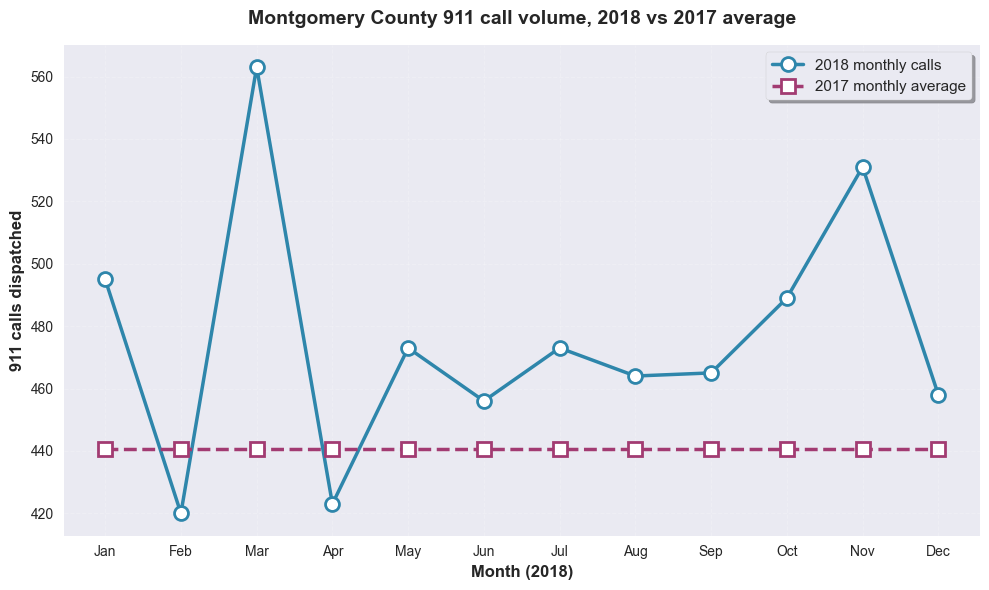

💡 Publication-quality: High resolution, professional styling, clean design
   Total 2018 calls charted: 5,710

Summary

✅ What you learned:
   1. Customization: Colors, fonts, styles, grid, legends
   2. Annotations: peak callouts and conditional markers, both computed from the data
   3. Presentation quality: resolution, spines, muted grid, direct value labels

🎯 Rule of thumb: every number printed on a chart should be READ from the data,
   never typed in by hand - that is how charts stay true after the data updates.

📚 Next Steps:
   - Example 07: Visualization Best Practices

✅ Customization and annotation - complete!


In [6]:
# WHAT: Produce the publication-quality version of the same real chart.
# WHY: High resolution, muted grid, no top/right spines - the details reviewers notice.

# Ensure data and figure are available from previous cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load() comes from the data-setup cell in Part 1 above - run that cell first.

# Real data: the Montgomery County (PA) 911 dispatch log.
calls = load("montgomery_911_calls", prefer="sample",
             usecols=['timeStamp'], parse_dates=['timeStamp'])

# 2018 monthly call volume - the series we will style and annotate.
y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
monthly = y2018.groupby(y2018['timeStamp'].dt.month).size()

# Benchmark line: the 2017 monthly average. A real reference point, not an invented target.
y2017 = calls[(calls['timeStamp'] >= '2017-01-01') & (calls['timeStamp'] < '2018-01-01')]
baseline_2017 = y2017.groupby(y2017['timeStamp'].dt.month).size().mean()

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = pd.DataFrame({
    'month': MONTH_NAMES,
    'calls': monthly.reindex(range(1, 13)).values,
    'baseline': [baseline_2017] * 12,
})

# Create figure for plotting
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.plot(data['month'], data['calls'], marker='o', linewidth=2.5, markersize=10,
        color='#2E86AB', label='2018 monthly calls', markerfacecolor='white',
        markeredgewidth=2, markeredgecolor='#2E86AB')
ax.plot(data['month'], data['baseline'], marker='s', linewidth=2.5, markersize=10,
        color='#A23B72', label='2017 monthly average', linestyle='--',
        markerfacecolor='white', markeredgewidth=2, markeredgecolor='#A23B72')

ax.set_xlabel('Month (2018)', fontsize=12, fontweight='bold')
ax.set_ylabel('911 calls dispatched', fontsize=12, fontweight='bold')
ax.set_title('Montgomery County 911 call volume, 2018 vs 2017 average',
             fontsize=14, fontweight='bold', pad=15)

ax.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save as high-resolution
# plt.savefig('911_calls_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("💡 Publication-quality: High resolution, professional styling, clean design")
print(f"   Total 2018 calls charted: {data['calls'].sum():,}")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("""
✅ What you learned:
   1. Customization: Colors, fonts, styles, grid, legends
   2. Annotations: peak callouts and conditional markers, both computed from the data
   3. Presentation quality: resolution, spines, muted grid, direct value labels

🎯 Rule of thumb: every number printed on a chart should be READ from the data,
   never typed in by hand - that is how charts stay true after the data updates.

📚 Next Steps:
   - Example 07: Visualization Best Practices
""")
print("✅ Customization and annotation - complete!")

## ⚠️ Where this breaks

- **Styling can manufacture a finding.** A colour map with uneven luminance creates
  apparent edges; a highlight colour creates importance; a smoothed line creates a trend.
  None of those are in the numbers. The test: would the same reader reach the same
  conclusion from the table?
- **Annotations rot.** An arrow positioned at fixed coordinates, or a label that says
  "peak: March", is correct for exactly this version of the data. When the file updates,
  hand-placed text silently points at the wrong bar. Compute both the value *and* its
  position, as the cells above do.
- **Colour is the least reliable channel you have.** Roughly 1 in 12 men has a colour-vision
  deficiency; charts get printed in greyscale, projected on washed-out beamers, and
  screenshotted at low quality. Never encode a distinction *only* in hue — pair it with
  position, shape, line style or a direct label.
- **The assumption that must hold: the reader will look where you point.** Emphasis works
  by suppressing everything else, which means you have decided for them what does not
  matter. If the chart's purpose is exploration rather than persuasion, that suppression is
  a defect, not a feature.
- **Over-customisation is its own failure mode.** Every extra colour, gradient, shadow and
  border is ink the reader must process and discard. Tufte's data-ink argument is not
  aesthetic minimalism; it is a claim about cognitive load.
- **Cheaper alternative:** set a style once (`plt.style.use`, a `matplotlibrc`, or a
  seaborn theme) and spend your effort on the *one* annotation that states the finding.
  A plain chart with one well-chosen sentence on it beats a beautifully styled chart the
  reader has to interpret alone.


## 📚 References

1. Tufte, E. R. (2001). *The Visual Display of Quantitative Information*, 2nd ed. Graphics Press.
2. Cleveland, W. S., & McGill, R. (1984). *Graphical Perception: Theory, Experimentation, and Application to the Development of Graphical Methods*. Journal of the American Statistical Association, 79(387), 531-554. <https://doi.org/10.1080/01621459.1984.10478080>
3. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90-95. <https://doi.org/10.1109/MCSE.2007.55>
4. Xie, Y., Zhang, Z., Wu, Y., et al. (2025). *VisJudge-Bench: Aesthetics and Quality Assessment of Visualizations*. arXiv:2510.22373. <https://arxiv.org/abs/2510.22373>
5. Chen, N., Zhang, Y., Xu, J., Ren, K., & Yang, Y. (2024). *VisEval: A Benchmark for Data Visualization in the Era of Large Language Models*. arXiv:2407.00981. <https://arxiv.org/abs/2407.00981>
